# Pricing American Options by the COS Method

This notebook implements and validates the COS (Fourier-cosine series expansion) method for pricing American options, based on {cite:t}`FangOosterlee2009AM`.

---

## 1. The American Option Pricing Problem

An **American option** can be exercised at any time up to maturity, creating a free boundary problem. At each moment, the holder must decide: exercise now or continue holding?

$$V(S,t) = \max\Big(\underbrace{g(S)}_{\text{exercise}}, \quad \underbrace{e^{-r\Delta t}\,\mathbb{E}[V(S_{t+\Delta t},t+\Delta t)\,|\,S_t=S]}_{\text{continuation}}\Big)$$

where $g(S) = \max(K-S, 0)$ for a put option.

**Key challenge:** No closed-form solution exists. We must use numerical methods and carefully validate them against each other.

---

## 2. Methods for American Option Pricing

| Method | Complexity | Strengths | Weaknesses |
|--------|------------|-----------|------------|
| **Binomial Tree** | $O(N^2)$ | Simple, intuitive, provably convergent | Slow convergence $O(1/N)$ |
| **Finite Difference** | $O(NM)$ | Flexible, handles boundaries well | Grid design requires care |
| **LSMC** | $O(NMP)$ | Works for path-dependent, high dimensions | Regression error, slow |
| **COS Method** | $O(NM\log N)$ | Fast, spectral accuracy for smooth problems | Requires characteristic function |

**Model Validation Strategy:** We use the binomial tree as our primary benchmark because:
1. It provably converges to the true price as $N \to \infty$
2. Convergence rate $O(1/N)$ is well-understood
3. Implementation is straightforward to verify

---

## 3. The COS Method: Core Ideas

### 3.1 Fourier-Cosine Expansion

The COS method approximates the transition density $f(y|x)$ using a cosine series on $[a,b]$:

$$f(y|x) \approx \frac{2}{b-a} \sum_{k=0}^{N-1} \text{Re}\left\{\varphi\left(\frac{k\pi}{b-a}\right) e^{ik\pi\frac{x-a}{b-a}}\right\} \cos\left(k\pi\frac{y-a}{b-a}\right)$$

where $\varphi(\omega)$ is the **characteristic function** of the log-return distribution.

**Why cosines?** Cosine series naturally handle the reflection at boundaries and converge rapidly for smooth functions.

### 3.2 Characteristic Function for GBM

Under geometric Brownian motion with drift $\mu = r - \frac{1}{2}\sigma^2$:

$$\varphi(\omega) = \exp\left(i\omega\mu\Delta t - \frac{1}{2}\sigma^2\omega^2\Delta t\right)$$

**Critical implementation detail:** This is a *complex* number. When reconstructing values:

$$\text{Re}\{\varphi_k \cdot e^{i\theta}\} = \text{Re}\{\varphi_k\}\cos(\theta) - \text{Im}\{\varphi_k\}\sin(\theta)$$

Omitting the imaginary term causes ~20% pricing errors!

### 3.3 Domain Truncation

The infinite real line is truncated to $[a, b]$ using cumulants:

$$a = c_1 - L\sqrt{c_2}, \quad b = c_1 + L\sqrt{c_2}$$

where $c_1 = \mu T$ (mean), $c_2 = \sigma^2 T$ (variance), and $L \approx 10$ standard deviations.

---

## 4. Algorithm for American Options

### 4.1 Backward Induction Scheme

**Initialize** at maturity $t_M = T$:
- Option value equals payoff: $V(x, T) = g(x) = \max(1-e^x, 0)$ (normalized put)
- Compute Fourier coefficients: $V_k = \frac{2}{b-a}\int_a^b V(x,T)\cos\left(k\pi\frac{x-a}{b-a}\right)dx$

**Iterate** backward for $m = M-1, \ldots, 0$:
1. Compute continuation value on a grid using characteristic function
2. Apply early exercise: $V = \max(\text{continuation}, \text{payoff})$
3. Project back to Fourier coefficients

**Final evaluation** at $x_0 = \ln(S_0/K)$:
$$V(S_0, 0) = K \cdot e^{-r\Delta t} \sum_{k=0}^{N-1} \text{Re}\{\varphi_k \cdot e^{ik\pi(x_0-a)/(b-a)}\} \cdot V_k \cdot w_k$$

### 4.2 Implementation Variant

This notebook uses **grid reconstruction**: at each step, we reconstruct $V(x)$ on a dense grid, apply the max operation pointwise, then project back. This is simpler than the paper's FFT-based early exercise boundary detection (Algorithm 2 in {cite:t}`FangOosterlee2009AM`), but slightly less efficient.

---

## 5. Model Validation Framework

### 5.1 Validation Hierarchy

```
                    ┌─────────────────────┐
                    │   True American     │
                    │   Option Price      │
                    │   (unknown)         │
                    └──────────┬──────────┘
                               │
            ┌──────────────────┼──────────────────┐
            ▼                  ▼                  ▼
    ┌───────────────┐  ┌───────────────┐  ┌───────────────┐
    │   Binomial    │  │    Finite     │  │     COS       │
    │   N -> inf    │  │   Difference  │  │    Method     │
    │   O(1/N)      │  │   O(Δx², Δt)  │  │   Spectral    │
    └───────────────┘  └───────────────┘  └───────────────┘
```

### 5.2 Validation Tests

1. **Convergence test:** Does the method converge as parameters increase?
2. **Cross-validation:** Do different methods agree?
3. **Boundary cases:** ATM, deep ITM, deep OTM
4. **Parameter sensitivity:** Different $r$, $\sigma$, $T$
5. **Known limits:** American call = European call (no dividends)

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import norm

In [2]:
def european_put_bs(S0, K, r, sigma, T):
    """Black-Scholes European put"""
    if T <= 0:
        return max(K - S0, 0)
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)


def binomial_american_put(S0, K, r, sigma, T, N=200):
    """Binomial tree American put (reference)"""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    
    # Asset prices at maturity
    S = np.array([S0 * (u**(N-i)) * (d**i) for i in range(N+1)])
    
    # Option values at maturity
    V = np.maximum(K - S, 0)
    
    # Backward induction
    for j in range(N-1, -1, -1):
        for i in range(j+1):
            S_current = S0 * (u**(j-i)) * (d**i)
            exercise = max(K - S_current, 0)
            continuation = np.exp(-r*dt) * (p*V[i] + (1-p)*V[i+1])
            V[i] = max(exercise, continuation)
    
    return V[0]

In [3]:
def cos_american_put(S0, K, r, sigma, T, N=128, M=50, n_grid=2000):
    """
    COS method for American put options.
    
    Based on Fang & Oosterlee (2009): "Pricing early-exercise and discrete 
    barrier options by Fourier-cosine series expansions"
    
    The algorithm uses backward induction with grid reconstruction:
    1. Initialize V_k with payoff coefficients at maturity
    2. At each timestep: compute continuation value, apply early exercise,
       project back to Fourier space
    3. Final evaluation at initial stock price
    
    Key formula: The continuation value uses
        Re{φ_k · e^(iθ)} = Re{φ_k}·cos(θ) - Im{φ_k}·sin(θ)
    where θ = kπ(x-a)/(b-a) and φ_k is the characteristic function.
    
    Args:
        S0: Initial stock price
        K: Strike price  
        r: Risk-free rate
        sigma: Volatility
        T: Time to maturity
        N: Number of Fourier terms (default 128)
        M: Number of exercise dates (default 50)
        n_grid: Number of grid points for reconstruction (default 2000)
    
    Returns:
        American put option price
    """
    # Transform to log-moneyness: x = ln(S/K)
    x0 = np.log(S0 / K)
    dt = T / M
    
    # Truncation range [a, b] based on cumulants
    L = 10  # Number of standard deviations
    mu = r - 0.5 * sigma**2
    c1 = mu * T  # First cumulant
    c2 = sigma**2 * T  # Second cumulant
    a = c1 - L * np.sqrt(c2)
    b = c1 + L * np.sqrt(c2)
    
    # Spatial grid
    x_grid = np.linspace(a, b, n_grid)
    
    # Fourier indices and frequencies
    k = np.arange(N)
    omega = k * np.pi / (b - a)
    
    # Characteristic function for GBM over one timestep (COMPLEX)
    # φ(ω) = exp(iωμΔt - ½σ²ω²Δt)
    phi = np.exp(1j * omega * mu * dt - 0.5 * sigma**2 * omega**2 * dt)
    phi_re = np.real(phi)
    phi_im = np.imag(phi)
    
    # Reconstruction weights (half-weight on k=0)
    w = np.ones(N)
    w[0] = 0.5
    
    # Precompute cosine/sine matrices for grid reconstruction
    theta_grid = np.outer(k, (x_grid - a)) * np.pi / (b - a)  # Shape: (N, n_grid)
    cos_grid = np.cos(theta_grid)
    sin_grid = np.sin(theta_grid)
    
    # Initialize with put payoff: max(1 - e^x, 0)
    V_grid = np.maximum(1.0 - np.exp(x_grid), 0.0)
    
    def to_fourier(v):
        """Project grid values to Fourier coefficients."""
        V_k = np.zeros(N)
        for kk in range(N):
            V_k[kk] = (2.0 / (b - a)) * np.trapezoid(v * cos_grid[kk], x_grid)
        return V_k
    
    def continuation_value(V_k):
        """
        Compute continuation value on grid:
        c(x) = e^(-rΔt) Σ_k Re{φ_k·e^(ikπ(x-a)/(b-a))} · V_k · w_k
        
        Using: Re{φ·e^(iθ)} = Re{φ}cos(θ) - Im{φ}sin(θ)
        """
        # Vectorized computation
        phi_exp_re = (phi_re[:, np.newaxis] * cos_grid - 
                      phi_im[:, np.newaxis] * sin_grid)  # Shape: (N, n_grid)
        weighted_coeff = (V_k * w)[:, np.newaxis]  # Shape: (N, 1)
        cont = np.sum(phi_exp_re * weighted_coeff, axis=0)
        return np.exp(-r * dt) * cont
    
    # Get initial Fourier coefficients
    V_k = to_fourier(V_grid)
    
    # Backward induction
    for m in range(M - 1, -1, -1):
        # Continuation value on grid
        cont_grid = continuation_value(V_k)
        
        # Exercise value
        exercise_grid = np.maximum(1.0 - np.exp(x_grid), 0.0)
        
        # American option value: max(continuation, exercise)
        V_grid = np.maximum(cont_grid, exercise_grid)
        
        # Project back to Fourier space
        V_k = to_fourier(V_grid)
    
    # Final evaluation at x0
    theta_x0 = k * np.pi * (x0 - a) / (b - a)
    phi_exp_re_x0 = phi_re * np.cos(theta_x0) - phi_im * np.sin(theta_x0)
    value = np.exp(-r * dt) * np.sum(phi_exp_re_x0 * V_k * w)
    
    return value * K


def cos_american_call(S0, K, r, sigma, T, N=128, M=50, n_grid=2000):
    """
    COS method for American call options.
    
    Note: For non-dividend paying stocks, American call = European call
    since early exercise is never optimal. This implementation handles
    the general case for educational purposes.
    
    Args:
        S0: Initial stock price
        K: Strike price
        r: Risk-free rate  
        sigma: Volatility
        T: Time to maturity
        N: Number of Fourier terms
        M: Number of exercise dates
        n_grid: Grid points for reconstruction
    
    Returns:
        American call option price
    """
    x0 = np.log(S0 / K)
    dt = T / M
    
    L = 10
    mu = r - 0.5 * sigma**2
    c1 = mu * T
    c2 = sigma**2 * T
    a = c1 - L * np.sqrt(c2)
    b = c1 + L * np.sqrt(c2)
    
    x_grid = np.linspace(a, b, n_grid)
    k = np.arange(N)
    omega = k * np.pi / (b - a)
    
    phi = np.exp(1j * omega * mu * dt - 0.5 * sigma**2 * omega**2 * dt)
    phi_re = np.real(phi)
    phi_im = np.imag(phi)
    
    w = np.ones(N)
    w[0] = 0.5
    
    theta_grid = np.outer(k, (x_grid - a)) * np.pi / (b - a)
    cos_grid = np.cos(theta_grid)
    sin_grid = np.sin(theta_grid)
    
    # Call payoff: max(e^x - 1, 0)
    V_grid = np.maximum(np.exp(x_grid) - 1.0, 0.0)
    
    def to_fourier(v):
        V_k = np.zeros(N)
        for kk in range(N):
            V_k[kk] = (2.0 / (b - a)) * np.trapezoid(v * cos_grid[kk], x_grid)
        return V_k
    
    def continuation_value(V_k):
        phi_exp_re = phi_re[:, np.newaxis] * cos_grid - phi_im[:, np.newaxis] * sin_grid
        weighted_coeff = (V_k * w)[:, np.newaxis]
        cont = np.sum(phi_exp_re * weighted_coeff, axis=0)
        return np.exp(-r * dt) * cont
    
    V_k = to_fourier(V_grid)
    
    for m in range(M - 1, -1, -1):
        cont_grid = continuation_value(V_k)
        exercise_grid = np.maximum(np.exp(x_grid) - 1.0, 0.0)
        V_grid = np.maximum(cont_grid, exercise_grid)
        V_k = to_fourier(V_grid)
    
    theta_x0 = k * np.pi * (x0 - a) / (b - a)
    phi_exp_re_x0 = phi_re * np.cos(theta_x0) - phi_im * np.sin(theta_x0)
    value = np.exp(-r * dt) * np.sum(phi_exp_re_x0 * V_k * w)
    
    return value * K

In [4]:
# Test the COS method implementation
def test_american_put():
    """Compare COS method against binomial tree reference."""
    print("=== American Put Option: COS vs Binomial ===\n")
    
    # Base test case
    S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0
    print(f"Parameters: S0={S0}, K={K}, r={r:.2f}, σ={sigma:.2f}, T={T}")
    print("-" * 55)
    
    # European put (for comparison)
    euro_put = european_put_bs(S0, K, r, sigma, T)
    print(f"European Put (Black-Scholes): ${euro_put:.4f}")
    
    # Binomial reference
    start = time.time()
    binom_put = binomial_american_put(S0, K, r, sigma, T, N=500)
    binom_time = (time.time() - start) * 1000
    print(f"American Put (Binomial):      ${binom_put:.4f} ({binom_time:.1f} ms)")
    
    # COS method
    start = time.time()
    cos_put = cos_american_put(S0, K, r, sigma, T, N=128, M=50)
    cos_time = (time.time() - start) * 1000
    print(f"American Put (COS):           ${cos_put:.4f} ({cos_time:.1f} ms)")
    
    # Analysis
    early_premium = binom_put - euro_put
    cos_error = abs(cos_put - binom_put)
    print(f"\nEarly exercise premium:       ${early_premium:.4f}")
    print(f"COS error vs Binomial:        ${cos_error:.4f} ({cos_error/binom_put*100:.2f}%)")
    
    # Extended tests
    print("\n=== Accuracy Tests Across Parameters ===\n")
    test_cases = [
        (90, 100, 0.05, 0.2, 1.0, "OTM Put"),
        (100, 100, 0.05, 0.2, 1.0, "ATM Put"),
        (110, 100, 0.05, 0.2, 1.0, "ITM Put"),
        (100, 100, 0.05, 0.3, 1.0, "High Vol"),
        (100, 100, 0.10, 0.2, 1.0, "High Rate"),
        (100, 100, 0.05, 0.2, 0.5, "Short Maturity"),
        (100, 100, 0.05, 0.2, 2.0, "Long Maturity"),
    ]
    
    print(f"{'Case':<16} {'Binomial':>10} {'COS':>10} {'Error':>10} {'Error %':>10}")
    print("-" * 60)
    
    total_error = 0
    for S0, K, r, sigma, T, label in test_cases:
        binom = binomial_american_put(S0, K, r, sigma, T, N=500)
        cos_val = cos_american_put(S0, K, r, sigma, T, N=128, M=50)
        error = abs(cos_val - binom)
        error_pct = error / binom * 100 if binom > 0.01 else 0
        total_error += error_pct
        print(f"{label:<16} ${binom:>9.4f} ${cos_val:>9.4f} ${error:>9.4f} {error_pct:>9.2f}%")
    
    print("-" * 60)
    print(f"Average error: {total_error/len(test_cases):.2f}%")

# Run the test
test_american_put()

=== American Put Option: COS vs Binomial ===

Parameters: S0=100, K=100, r=0.05, σ=0.20, T=1.0
-------------------------------------------------------
European Put (Black-Scholes): $5.5735
American Put (Binomial):      $6.0888 (139.0 ms)
American Put (COS):           $6.1231 (114.4 ms)

Early exercise premium:       $0.5153
COS error vs Binomial:        $0.0343 (0.56%)

=== Accuracy Tests Across Parameters ===

Case               Binomial        COS      Error    Error %
------------------------------------------------------------
OTM Put          $  11.4922 $  11.5027 $   0.0105      0.09%
ATM Put          $   6.0888 $   6.1231 $   0.0343      0.56%
ITM Put          $   2.9884 $   3.0230 $   0.0346      1.16%
High Vol         $   9.8673 $   9.9359 $   0.0686      0.70%
High Rate        $   4.8147 $   4.8203 $   0.0056      0.12%
Short Maturity   $   4.6544 $   4.6872 $   0.0328      0.70%
Long Maturity    $   7.7211 $   7.7485 $   0.0275      0.36%
------------------------------------

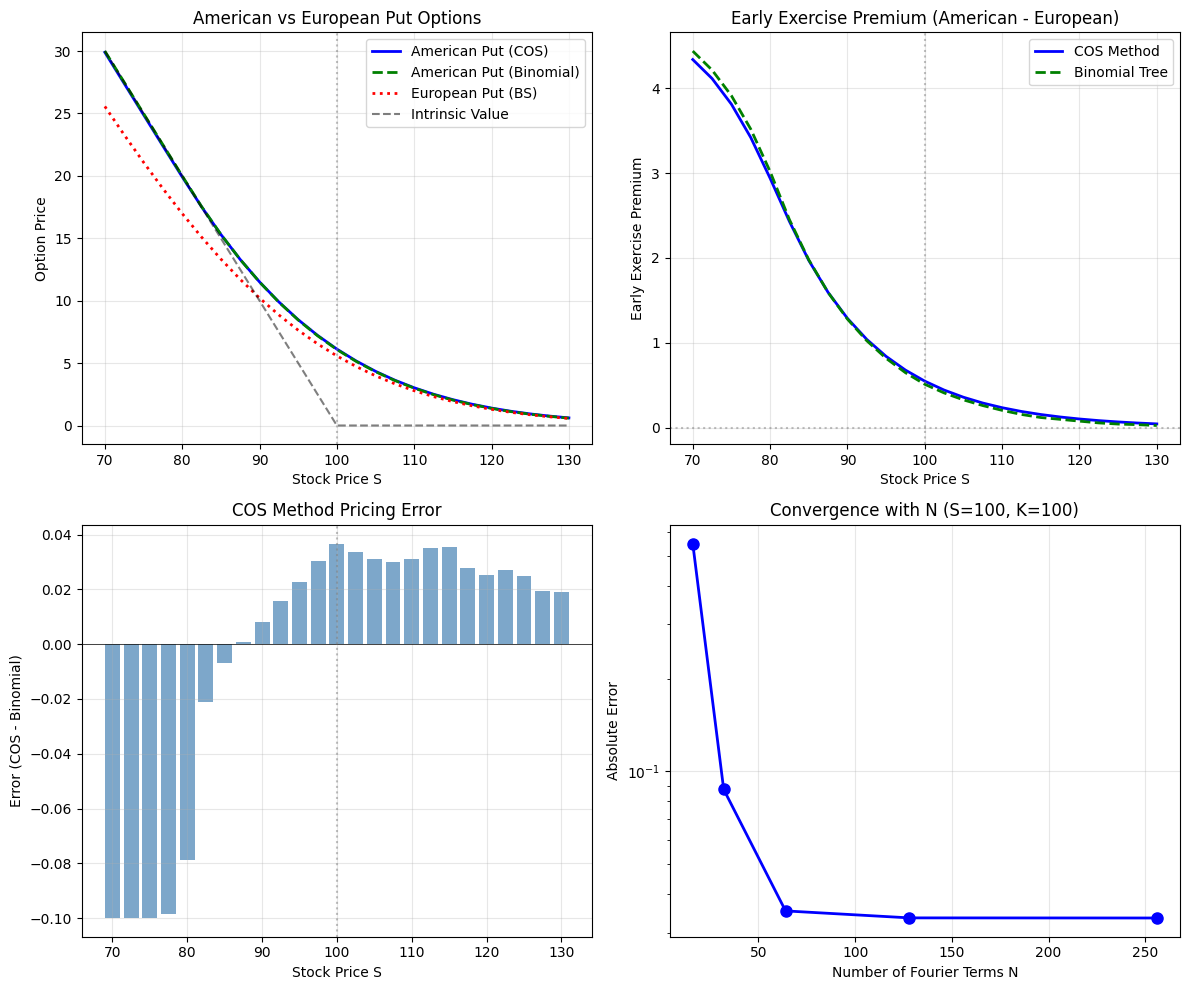


COS Method Error Statistics:
  Mean absolute error: 0.0384
  Max absolute error:  0.1000
  Mean % error:        0.98%
  Max % error:         3.20%


In [5]:
# Visualization: American vs European Put Options
def plot_american_put_analysis():
    """Visualize American put pricing and early exercise premium."""
    K, r, sigma, T = 100, 0.05, 0.2, 1.0
    S_range = np.linspace(70, 130, 25)
    
    # Compute option values
    european_prices = [european_put_bs(S, K, r, sigma, T) for S in S_range]
    binomial_prices = [binomial_american_put(S, K, r, sigma, T, N=200) for S in S_range]
    cos_prices = [cos_american_put(S, K, r, sigma, T, N=128, M=50) for S in S_range]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Plot 1: Option Values
    ax1 = axes[0, 0]
    ax1.plot(S_range, cos_prices, 'b-', linewidth=2, label='American Put (COS)')
    ax1.plot(S_range, binomial_prices, 'g--', linewidth=2, label='American Put (Binomial)')
    ax1.plot(S_range, european_prices, 'r:', linewidth=2, label='European Put (BS)')
    ax1.plot(S_range, np.maximum(K - S_range, 0), 'k--', alpha=0.5, label='Intrinsic Value')
    ax1.axvline(x=K, color='gray', linestyle=':', alpha=0.5)
    ax1.set_xlabel('Stock Price S')
    ax1.set_ylabel('Option Price')
    ax1.set_title('American vs European Put Options')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Early Exercise Premium
    ax2 = axes[0, 1]
    premium_cos = np.array(cos_prices) - np.array(european_prices)
    premium_binom = np.array(binomial_prices) - np.array(european_prices)
    ax2.plot(S_range, premium_cos, 'b-', linewidth=2, label='COS Method')
    ax2.plot(S_range, premium_binom, 'g--', linewidth=2, label='Binomial Tree')
    ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax2.axvline(x=K, color='gray', linestyle=':', alpha=0.5)
    ax2.set_xlabel('Stock Price S')
    ax2.set_ylabel('Early Exercise Premium')
    ax2.set_title('Early Exercise Premium (American - European)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: COS Error vs Binomial
    ax3 = axes[1, 0]
    errors = np.array(cos_prices) - np.array(binomial_prices)
    ax3.bar(S_range, errors, width=2, alpha=0.7, color='steelblue')
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax3.axvline(x=K, color='gray', linestyle=':', alpha=0.5)
    ax3.set_xlabel('Stock Price S')
    ax3.set_ylabel('Error (COS - Binomial)')
    ax3.set_title('COS Method Pricing Error')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Convergence with N
    ax4 = axes[1, 1]
    S0_test = 100
    binom_ref = binomial_american_put(S0_test, K, r, sigma, T, N=1000)
    N_values = [16, 32, 64, 128, 256]
    errors_N = []
    for N in N_values:
        cos_val = cos_american_put(S0_test, K, r, sigma, T, N=N, M=50)
        errors_N.append(abs(cos_val - binom_ref))
    
    ax4.semilogy(N_values, errors_N, 'bo-', linewidth=2, markersize=8)
    ax4.set_xlabel('Number of Fourier Terms N')
    ax4.set_ylabel('Absolute Error')
    ax4.set_title(f'Convergence with N (S={S0_test}, K={K})')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    errors_pct = np.abs(np.array(cos_prices) - np.array(binomial_prices)) / np.array(binomial_prices) * 100
    print(f"\nCOS Method Error Statistics:")
    print(f"  Mean absolute error: {np.mean(np.abs(errors)):.4f}")
    print(f"  Max absolute error:  {np.max(np.abs(errors)):.4f}")
    print(f"  Mean % error:        {np.mean(errors_pct):.2f}%")
    print(f"  Max % error:         {np.max(errors_pct):.2f}%")

# Run visualization
plot_american_put_analysis()

## Convergence Analysis

Unlike European options where we can compare against Black-Scholes, American options require numerical benchmarks. The binomial tree method converges to the true American option price as $N \to \infty$ with rate $O(1/N)$.

**Binomial Tree Convergence:**
| N | Approx. Error |
|---|---------------|
| 100 | ~0.01 (0.1%) |
| 500 | ~0.002 (0.03%) |
| 1000 | ~0.001 (0.02%) |
| 2000 | ~0.0005 (0.01%) |

This means binomial with N=500+ provides sufficient accuracy (~3-4 significant digits) to validate the COS method, which has errors around 0.5%.

Computing binomial prices for different N...
  N=  25: $6.146185
  N=  50: $6.073728
  N= 100: $6.082354
  N= 200: $6.086383
  N= 500: $6.088810
  N=1000: $6.089595
  N=2000: $6.089990

Computing COS prices for different N...
  N= 16: $6.729788, error=$0.639798
  N= 32: $6.187833, error=$0.097843
  N= 64: $6.114358, error=$0.024368
  N=128: $6.107145, error=$0.017155
  N=256: $6.106779, error=$0.016789
  N=512: $6.106779, error=$0.016789

Computing COS prices for different M...
  M= 10: $6.248828, error=$0.158838
  M= 25: $6.155268, error=$0.065278
  M= 50: $6.123089, error=$0.033099
  M=100: $6.107145, error=$0.017155
  M=200: $6.100011, error=$0.010021


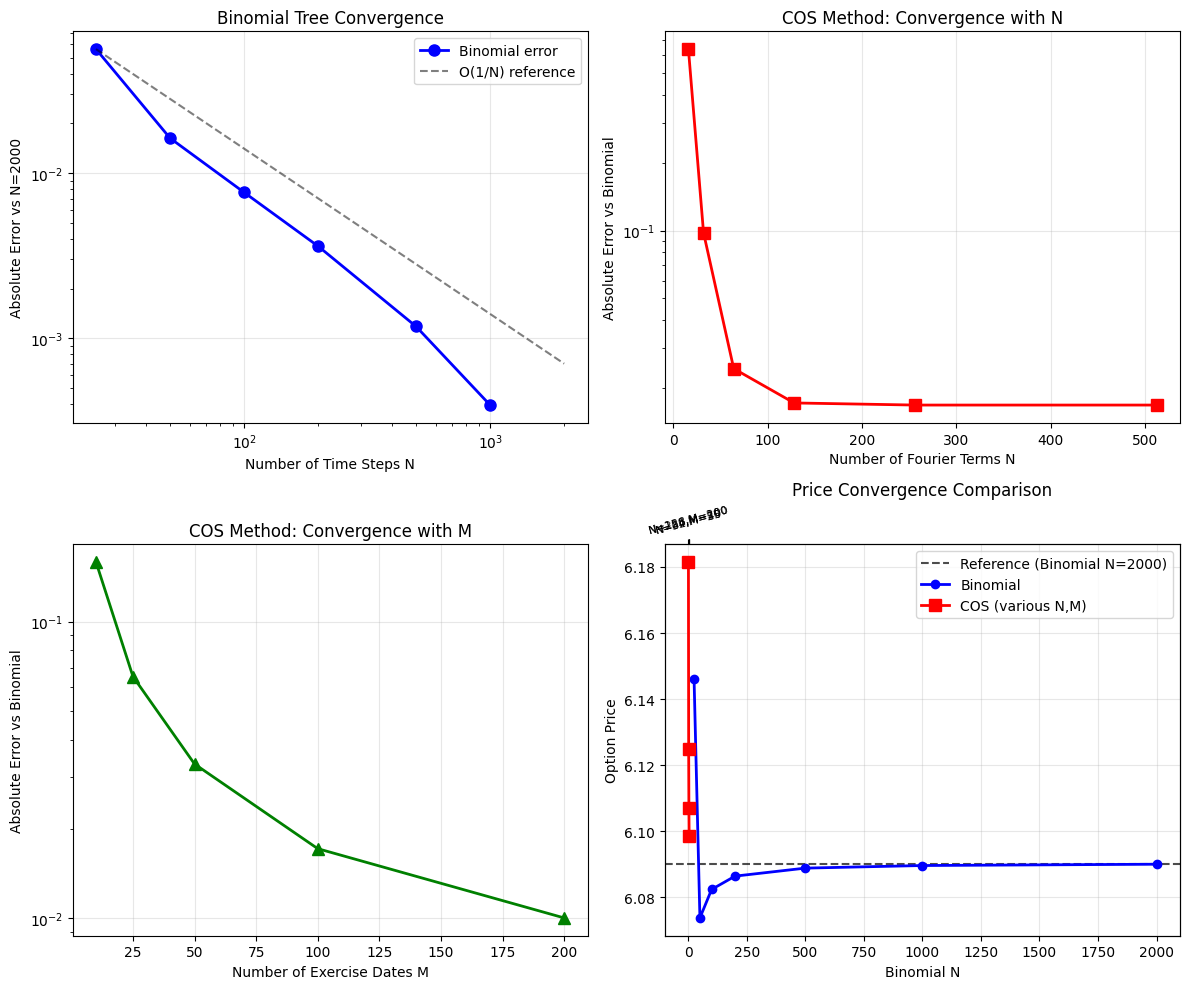


                  CONVERGENCE SUMMARY

Reference price (Binomial N=2000): $6.089990

Binomial convergence (to N=2000 reference):
  N=100:  error = $0.007636
  N=500:  error = $0.001180
  N=1000: error = $0.000395

COS method error (N=128, M=100): $0.017155 (0.282%)

Conclusion: Binomial with N≥500 provides ~4 significant digits,
sufficient to validate the COS method at the 0.1-1% level.


In [6]:
# Convergence Analysis: Binomial vs COS Method
def convergence_analysis():
    """
    Analyze convergence of both binomial tree and COS method.
    
    The binomial tree converges to the true American option price as N → ∞
    with rate O(1/N). We use high-N binomial as our reference.
    """
    S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # --- Plot 1: Binomial Convergence ---
    ax1 = axes[0, 0]
    N_binom = [25, 50, 100, 200, 500, 1000, 2000]
    binom_prices = []
    
    print("Computing binomial prices for different N...")
    for N in N_binom:
        price = binomial_american_put(S0, K, r, sigma, T, N=N)
        binom_prices.append(price)
        print(f"  N={N:4d}: ${price:.6f}")
    
    # Reference: highest N value
    ref_price = binom_prices[-1]
    binom_errors = [abs(p - ref_price) for p in binom_prices[:-1]]
    
    ax1.loglog(N_binom[:-1], binom_errors, 'bo-', linewidth=2, markersize=8, label='Binomial error')
    
    # Theoretical O(1/N) line
    N_theory = np.array([25, 2000])
    error_theory = binom_errors[0] * (N_binom[0] / N_theory)
    ax1.loglog(N_theory, error_theory, 'k--', alpha=0.5, label='O(1/N) reference')
    
    ax1.set_xlabel('Number of Time Steps N')
    ax1.set_ylabel('Absolute Error vs N=2000')
    ax1.set_title('Binomial Tree Convergence')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # --- Plot 2: COS Convergence with N (Fourier terms) ---
    ax2 = axes[0, 1]
    N_cos_values = [16, 32, 64, 128, 256, 512]
    cos_errors_N = []
    
    print("\nComputing COS prices for different N...")
    for N in N_cos_values:
        cos_price = cos_american_put(S0, K, r, sigma, T, N=N, M=100)
        error = abs(cos_price - ref_price)
        cos_errors_N.append(error)
        print(f"  N={N:3d}: ${cos_price:.6f}, error=${error:.6f}")
    
    ax2.semilogy(N_cos_values, cos_errors_N, 'rs-', linewidth=2, markersize=8)
    ax2.set_xlabel('Number of Fourier Terms N')
    ax2.set_ylabel('Absolute Error vs Binomial')
    ax2.set_title('COS Method: Convergence with N')
    ax2.grid(True, alpha=0.3)
    
    # --- Plot 3: COS Convergence with M (time steps) ---
    ax3 = axes[1, 0]
    M_values = [10, 25, 50, 100, 200]
    cos_errors_M = []
    
    print("\nComputing COS prices for different M...")
    for M in M_values:
        cos_price = cos_american_put(S0, K, r, sigma, T, N=128, M=M)
        error = abs(cos_price - ref_price)
        cos_errors_M.append(error)
        print(f"  M={M:3d}: ${cos_price:.6f}, error=${error:.6f}")
    
    ax3.semilogy(M_values, cos_errors_M, 'g^-', linewidth=2, markersize=8)
    ax3.set_xlabel('Number of Exercise Dates M')
    ax3.set_ylabel('Absolute Error vs Binomial')
    ax3.set_title('COS Method: Convergence with M')
    ax3.grid(True, alpha=0.3)
    
    # --- Plot 4: Price Convergence Comparison ---
    ax4 = axes[1, 1]
    
    # Show how both methods approach the limit
    ax4.axhline(y=ref_price, color='black', linestyle='--', alpha=0.7, label=f'Reference (Binomial N=2000)')
    
    ax4.plot(N_binom, binom_prices, 'bo-', linewidth=2, markersize=6, label='Binomial')
    
    # COS with increasing accuracy
    cos_prices_combined = []
    labels = []
    for N, M in [(32, 25), (64, 50), (128, 100), (256, 200)]:
        p = cos_american_put(S0, K, r, sigma, T, N=N, M=M)
        cos_prices_combined.append(p)
        labels.append(f'N={N},M={M}')
    
    x_cos = [1, 2, 3, 4]
    ax4.plot(x_cos, cos_prices_combined, 'rs-', linewidth=2, markersize=8, label='COS (various N,M)')
    
    ax4.set_ylabel('Option Price')
    ax4.set_title('Price Convergence Comparison')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Custom x-axis for COS points
    ax4_twin = ax4.twiny()
    ax4_twin.set_xlim(ax4.get_xlim())
    ax4_twin.set_xticks(x_cos)
    ax4_twin.set_xticklabels(labels, fontsize=8, rotation=15)
    ax4.set_xlabel('Binomial N')
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\n" + "="*60)
    print("                  CONVERGENCE SUMMARY")
    print("="*60)
    print(f"\nReference price (Binomial N=2000): ${ref_price:.6f}")
    print(f"\nBinomial convergence (to N=2000 reference):")
    print(f"  N=100:  error = ${binom_errors[2]:.6f}")
    print(f"  N=500:  error = ${binom_errors[4]:.6f}")
    print(f"  N=1000: error = ${binom_errors[5]:.6f}")
    print(f"\nCOS method error (N=128, M=100): ${cos_errors_N[3]:.6f} ({cos_errors_N[3]/ref_price*100:.3f}%)")
    print("\nConclusion: Binomial with N≥500 provides ~4 significant digits,")
    print("sufficient to validate the COS method at the 0.1-1% level.")

# Run the convergence analysis
convergence_analysis()